# Sickle cell anemia classification using ML techniques on Florence dataset with XAI

### Import Libraries

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# ML & preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb
import xgboost as xgb

# Deep learning
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.models import Model

### Extract VGG16 features

In [2]:
# Dataset path and classes
dataset_path = "/kaggle/input/sickle-cell-disease-dataset"  # your dataset folder
classes = ["Positive/Unlabelled","Negative/Clear"]

# Load VGG16 base model
base_model = VGG16(weights='imagenet', include_top=False)
feature_model = Model(inputs=base_model.input, outputs=base_model.output)

features = []
labels = []

for cls in classes:
    folder = os.path.join(dataset_path, cls)
    for file in tqdm(os.listdir(folder), desc=f"Processing {cls}"):
        img_path = os.path.join(folder, file)
        img = cv2.imread(img_path)
        if img is None:
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img_resized = cv2.resize(img, (224, 224))
        img_input = np.expand_dims(img_resized, axis=0)
        img_input = preprocess_input(img_input)

        # Extract features
        feat = feature_model.predict(img_input)
        features.append(feat.flatten())
        labels.append(cls)

features = np.array(features)
labels = np.array(labels)

# Save for later use
np.save("features.npy", features)
np.save("labels.npy", labels)

print("Features shape:", features.shape)
print("Labels shape:", labels.shape)

I0000 00:00:1762798268.203206      48 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1762798268.203985      48 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Processing Positive/Unlabelled:   0%|          | 0/422 [00:00<?, ?it/s]WARNING: All log messages before absl::InitializeLog() is called are written to STDERR
I0000 00:00:1762798270.623153     113 service.cc:148] XLA service 0x7871200053c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1762798270.624397     113 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1762798270.624416     113 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1762798270.759146     113 cuda_dnn.cc:529] Loaded cuDNN version 90300


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


I0000 00:00:1762798273.075339     113 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
Processing Positive/Unlabelled:   0%|          | 1/422 [00:02<19:38,  2.80s/it]

...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


Processing Negative/Clear:  99%|█████████▉| 146/147 [00:14<00:00,  9.12it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


Processing Negative/Clear: 100%|██████████| 147/147 [00:14<00:00, 10.06it/s]

Features shape: (569, 25088)
Labels shape: (569,)


### Prepare data for ML

In [3]:
# Load features and labels (if starting fresh)
# features = np.load("features.npy")
# labels = np.load("labels.npy")

# Encode labels
le = LabelEncoder()
y = le.fit_transform(labels)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    features, y, test_size=0.2, random_state=42, stratify=y
)
print("Train/Test shapes:", X_train.shape, X_test.shape)

Train/Test shapes: (455, 25088) (114, 25088)


### Occlusion Sensitivity

In [4]:
def occlusion_sensitivity(img_path, model, base_model, patch_size=30):
    """
    Compute occlusion sensitivity for any ML model trained on VGG16 features.
    Args:
        img_path: path to the test image
        model: trained ML model (e.g., SVM, RandomForest, etc.)
        base_model: pretrained CNN feature extractor (e.g., VGG16 without top)
        patch_size: size of occluded patch
    """
    from tensorflow.keras.preprocessing.image import load_img, img_to_array
    from tensorflow.keras.applications.vgg16 import preprocess_input
    import numpy as np
    import cv2

    # Load and preprocess image
    img = load_img(img_path, target_size=(224, 224))
    img_array = img_to_array(img)
    h, w, _ = img_array.shape

    # Extract VGG16 features for the base image
    feat_base = base_model.predict(preprocess_input(np.expand_dims(img_array, axis=0)))
    feat_base = feat_base.flatten().reshape(1, -1)

    # Base prediction and class confidence
    base_pred = model.predict_proba(feat_base)[0]
    base_class = np.argmax(base_pred)
    base_prob = base_pred[base_class]

    # Initialize heatmap
    heatmap = np.zeros((h, w))

    # Slide occlusion window
    for y in range(0, h, patch_size):
        for x in range(0, w, patch_size):
            occluded = img_array.copy()
            occluded[y:y+patch_size, x:x+patch_size, :] = 0  # black patch
            feat_occ = base_model.predict(preprocess_input(np.expand_dims(occluded, axis=0)))
            feat_occ = feat_occ.flatten().reshape(1, -1)

            pred_occ = model.predict_proba(feat_occ)[0]
            prob_occ = pred_occ[base_class]
            heatmap[y:y+patch_size, x:x+patch_size] = base_prob - prob_occ  # drop in confidence

    # Normalize heatmap
    heatmap = np.maximum(heatmap, 0)
    if np.max(heatmap) > 0:
        heatmap /= np.max(heatmap)

    return img_array, heatmap


# -----------------------------
# Visualization helper
# -----------------------------
import matplotlib.pyplot as plt
import cv2
import numpy as np

def show_overlay(img, heatmap):
    heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
    overlay = cv2.addWeighted(cv2.cvtColor(np.uint8(img), cv2.COLOR_RGB2BGR), 0.6, heatmap_color, 0.4, 0)
    
    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(np.uint8(img))
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    plt.title("Occlusion Sensitivity")
    plt.axis("off")

    plt.show()

### Image path

In [5]:
test_img = "/kaggle/input/sickle-cell-disease-dataset/Positive/Unlabelled/118.jpg"  # path to one test image

### Decision Tree

Decision Tree Accuracy: 0.7368421052631579
              precision    recall  f1-score   support

           0       0.48      0.45      0.46        29
           1       0.82      0.84      0.83        85

    accuracy                           0.74       114
   macro avg       0.65      0.64      0.64       114
weighted avg       0.73      0.74      0.73       114

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 452ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━

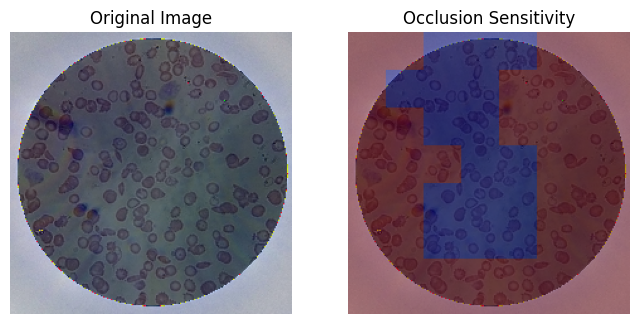

In [6]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

img, heatmap = occlusion_sensitivity(test_img, dt, base_model)
show_overlay(img, heatmap)

### Logistic Regression

Logistic Regression Accuracy: 0.8947368421052632
              precision    recall  f1-score   support

           0       0.87      0.69      0.77        29
           1       0.90      0.96      0.93        85

    accuracy                           0.89       114
   macro avg       0.89      0.83      0.85       114
weighted avg       0.89      0.89      0.89       114

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━

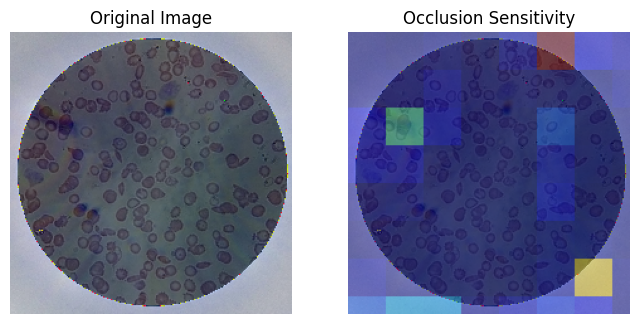

In [7]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

img, heatmap = occlusion_sensitivity(test_img, lr, base_model)
show_overlay(img, heatmap)

### LightGBM

[LightGBM] [Info] Number of positive: 337, number of negative: 118
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.127437 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 401988
[LightGBM] [Info] Number of data points in the train set: 455, number of used features: 7374
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.740659 -> initscore=1.049398
[LightGBM] [Info] Start training from score 1.049398
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

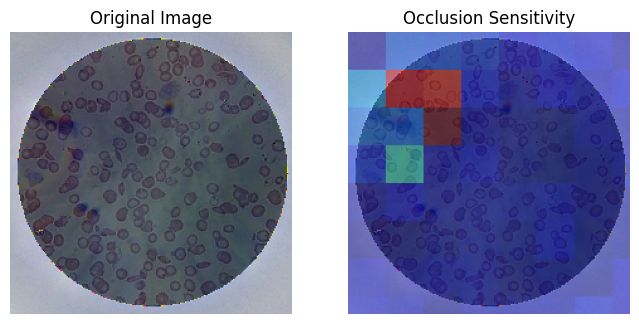

In [8]:
lgbm = lgb.LGBMClassifier()
lgbm.fit(X_train, y_train)
y_pred = lgbm.predict(X_test)
print("LightGBM Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

img, heatmap = occlusion_sensitivity(test_img, lgbm, base_model)
show_overlay(img, heatmap)

### SVM

SVM Accuracy: 0.8771929824561403
              precision    recall  f1-score   support

           0       0.94      0.55      0.70        29
           1       0.87      0.99      0.92        85

    accuracy                           0.88       114
   macro avg       0.90      0.77      0.81       114
weighted avg       0.89      0.88      0.87       114

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms

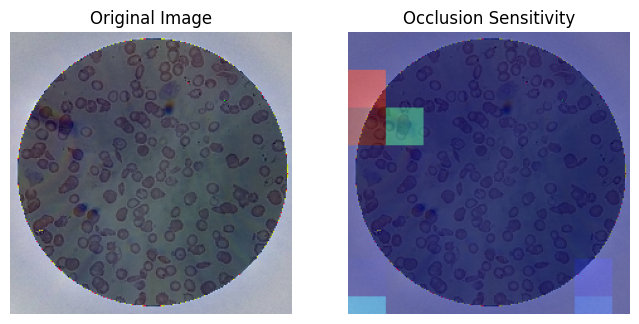

In [9]:
svm = SVC(probability=True)
svm.fit(X_train, y_train)
y_pred = svm.predict(X_test)
print("SVM Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

img, heatmap = occlusion_sensitivity(test_img, svm, base_model)
show_overlay(img, heatmap)

### Naive Bayes

Naive Bayes Accuracy: 0.8333333333333334
              precision    recall  f1-score   support

           0       0.92      0.38      0.54        29
           1       0.82      0.99      0.90        85

    accuracy                           0.83       114
   macro avg       0.87      0.68      0.72       114
weighted avg       0.85      0.83      0.81       114

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━

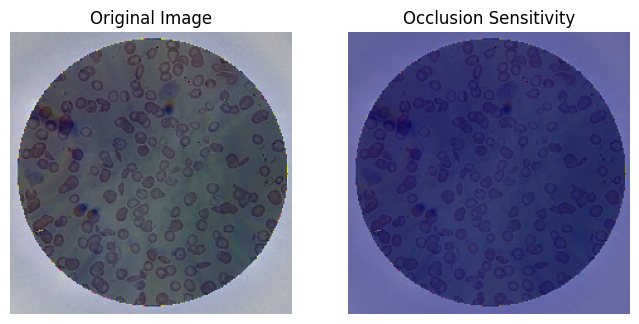

In [10]:
nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred = nb.predict(X_test)
print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

img, heatmap = occlusion_sensitivity(test_img, nb, base_model, patch_size=30)
show_overlay(img, heatmap)

### Random Forest

Random Forest Accuracy: 0.868421052631579
              precision    recall  f1-score   support

           0       1.00      0.48      0.65        29
           1       0.85      1.00      0.92        85

    accuracy                           0.87       114
   macro avg       0.93      0.74      0.79       114
weighted avg       0.89      0.87      0.85       114

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━

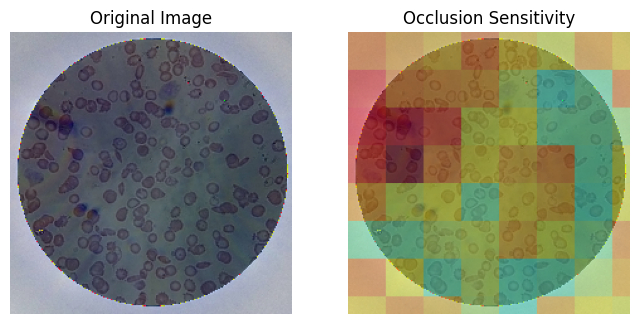

In [11]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

img, heatmap = occlusion_sensitivity(test_img, rf, base_model)
show_overlay(img, heatmap)

### XGBoost

XGBoost Accuracy: 0.9035087719298246
              precision    recall  f1-score   support

           0       1.00      0.62      0.77        29
           1       0.89      1.00      0.94        85

    accuracy                           0.90       114
   macro avg       0.94      0.81      0.85       114
weighted avg       0.91      0.90      0.90       114

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

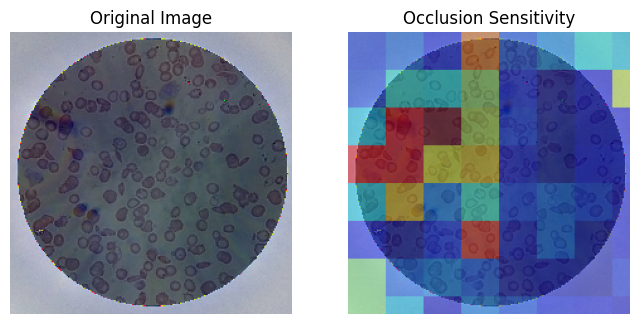

In [12]:
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)
y_pred = xgb_model.predict(X_test)
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

img, heatmap = occlusion_sensitivity(test_img, xgb_model, base_model, patch_size=30)
show_overlay(img, heatmap)

### KNN

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
print("KNN Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

img, heatmap = occlusion_sensitivity(test_img, knn, base_model)
show_overlay(img, heatmap)